In [1]:
import pandas as pd
import json

df_train = pd.read_csv('data/codex/train.txt', sep='\t', header=None, names=['Head','Relation','Tail'])
df_test = pd.read_csv('data/codex/test.txt', sep='\t', header=None, names=['Head','Relation','Tail'])
df_valid = pd.read_csv('data/codex/valid.txt', sep='\t', header=None, names=['Head','Relation','Tail'])

with open('data/codex/entities.json', 'r') as file:
    entities = json.load(file)

with open('data/codex/relations.json', 'r') as file:
    relations = json.load(file)

def id2name_df(id_df:pd.DataFrame, entities_dict:dict, relations_dict:dict)-> pd.DataFrame:
    name_dict = {}
    for id, row in id_df.iterrows():
        # get id
        head_id = row['Head']
        relation_id = row['Relation']
        tail_id = row['Tail']
        # get label out of id
        head = entities_dict[head_id]['label']
        relation = relations_dict[relation_id]['label']
        tail = entities_dict[tail_id]['label']
        name_dict[id] = [head,relation,tail]
    name_df = pd.DataFrame.from_dict(name_dict,orient='index',columns=['Head','Relation','Tail'])
    return name_df

df_train_name = id2name_df(df_train, entities, relations)
df_test_name = id2name_df(df_test, entities, relations)
df_valid_name = id2name_df(df_valid, entities, relations)

df_name = pd.concat([df_train_name, df_test_name, df_valid_name]).reset_index(drop=True)

/var/folders/_3/wtwzgv1d3rlfz233qkf36kg00000gp/T/ipykernel_27650/403170735.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
from cand_gen import triple_gen

df_name_sample = df_name.sample(int(0.8*len(df_name)))
candidates_df = triple_gen.generate_all_candidates(df_name_sample)


In [3]:
def compute_missing_df(original_df:pd.DataFrame, sample_df:pd.DataFrame) -> pd.DataFrame:
    df_missing = original_df[~df_name.apply(tuple, axis=1).isin(sample_df.apply(tuple, axis=1))]
    return df_missing

In [4]:
missing_df = compute_missing_df(df_name, df_name_sample)
cand_df = candidates_df[['Head','Relation','Tail']]
true_cand_df = cand_df[cand_df.apply(tuple, axis=1).isin(missing_df.apply(tuple, axis=1))]
false_cand_df = cand_df[~cand_df.apply(tuple, axis=1).isin(missing_df.apply(tuple, axis=1))]

In [11]:
true_cand_df['Missing'] = 1
false_cand_df['Missing'] = 0
df_size = 500
test_df = pd.concat([true_cand_df.sample(int(df_size/2)), false_cand_df.sample(int(df_size/2))])


/var/folders/_3/wtwzgv1d3rlfz233qkf36kg00000gp/T/ipykernel_27650/547850346.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  true_cand_df['Missing'] = 1
/var/folders/_3/wtwzgv1d3rlfz233qkf36kg00000gp/T/ipykernel_27650/547850346.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  false_cand_df['Missing'] = 0


In [12]:
test_df

,Head,Relation,Tail,Missing
611922,Haiti,diplomatic relation,Taiwan,1
913241,Frédéric Joliot-Curie,occupation,physicist,1
583492,Wang Leehom,instrument,harmonica,1
525513,Osip Mandelstam,ethnic group,Jewish people,1
492633,Vatican City,diplomatic relation,Saudi Arabia,1
...,...,...,...,...
708480,Nat King Cole,employer,University of Oxford,0
124967,Philippines,diplomatic relation,Slovakia,0
456893,André 3000,employer,Warner Bros.,0
405305,George Harrison,country of citizenship,Nazi Germany,0


In [13]:
import ollama
from llm_eval.utils import row2text

In [14]:
response_dict = {}
for index, row in test_df.iterrows():
    triple_text, head, relation, tail = row2text(row)

    prompt = f'Answer the following question by True or False only.'
    prompt += f"Is the fact present in the following sentence :'{triple_text}' valid."
    prompt += f'Answer the following question by True or False only.'
    #prompt += f"If you can't answer the question, answer false"
    response = ollama.generate(model='mistral', 
            prompt= prompt)
    text = response['response']
    response_dict[index] = text


In [41]:
response_dict_t = response_dict.copy()

In [42]:
list_reponse = []
for response in response_dict.values():
    response = response.lstrip()
    if response.startswith('False'):
        list_reponse.append(0)
    elif response.startswith('True'):
        list_reponse.append(1)
    else:
        list_reponse.append(2)
        #pass

In [44]:
test_df['Pred'] = list_reponse

In [45]:
test_df

,Head,Relation,Tail,Missing,Pred
611922,Haiti,diplomatic relation,Taiwan,1,2
913241,Frédéric Joliot-Curie,occupation,physicist,1,0
583492,Wang Leehom,instrument,harmonica,1,2
525513,Osip Mandelstam,ethnic group,Jewish people,1,0
492633,Vatican City,diplomatic relation,Saudi Arabia,1,1
...,...,...,...,...,...
708480,Nat King Cole,employer,University of Oxford,0,0
124967,Philippines,diplomatic relation,Slovakia,0,2
456893,André 3000,employer,Warner Bros.,0,2
405305,George Harrison,country of citizenship,Nazi Germany,0,1


In [50]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = test_df['Missing']
y_pred = test_df['Pred']
# List of classes (without undefined, initially)
classes = [0, 1]

# Compute the standard confusion matrix (ignoring undefined)
cm = confusion_matrix(y_true[y_pred != 2], y_pred[y_pred != 2], labels=classes)


,0,1,undefined
0,111,65,74
1,62,152,36
undefined,36,74,110


In [51]:
cm

array([[111,  65],
       [ 62, 152]])

In [60]:
undef_true = y_pred[y_true == 1] == 2
undef_false = y_pred[y_true == 0] == 2
nb_undef_true = undef_true.sum()
nb_undef_false = undef_false.sum()
undef = np.array([nb_undef_true, nb_undef_false])

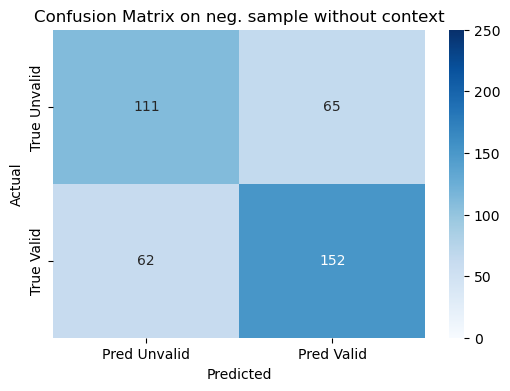

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
# Display the confusion matrix using seaborn heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Unvalid', 'Pred Valid'], yticklabels=['True Unvalid', 'True Valid'], vmin=0, vmax=250)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix on neg. sample without context')
plt.show()